In [ ]:
#pip install ipympl
#pip install mplcursors
#!pip install ipywidgets --upgrade

In [2]:
from IPython.display import Javascript, display
display(Javascript("window.IPython = window.IPython || {};"))

<IPython.core.display.Javascript object>

In [3]:
#Define data
#1 -Load directory where functions are stored
import sys, os
from pathlib import Path

cwdPath = Path.cwd().parent
for functionDir in [
    cwdPath / ".." / "Shared",
    cwdPath / "ThT_decay" / "functions"
]:
    sys.path.append(str(functionDir.resolve()))

#2 -Give file name and path
fileName = "25-08-13 13-33-10 ThT disaggregation 3 gains bag1m curve.CSV"
fileFolder =  r"D:\phd_leiden\experiments\fluostar\202508 tht disag\20250813"

In [4]:
#Load data and config
from loadData import FLUOstarData
data = FLUOstarData(fileFolder,fileName)

File read successfully


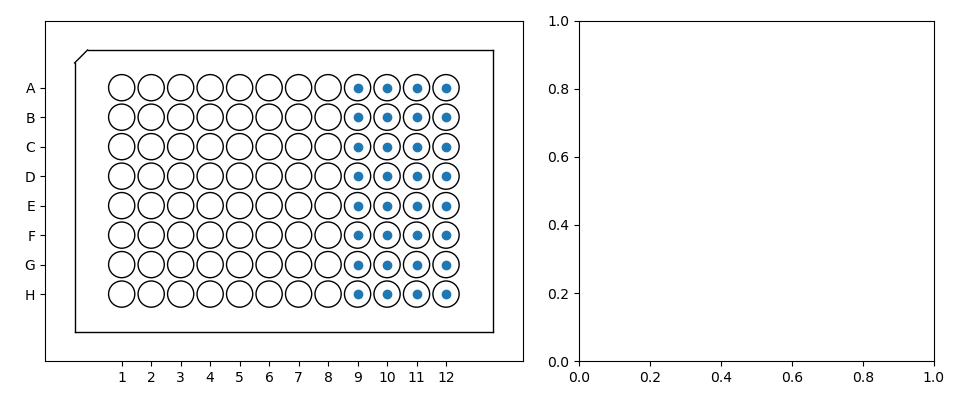

Button(description='Sort Selection', style=ButtonStyle())

In [5]:
#Data selection
%matplotlib widget
from selectData import Well96Selector
selector = Well96Selector(data)

In [6]:
#Pre-processing
data.set_gain(Gain=3)
data.data = data.data[data.data['Time [s]']>500] # Truncate

In [7]:
roi = selector.roi()
#Normalize data
from processData import NormalizeThT
norm = NormalizeThT(data,roi)

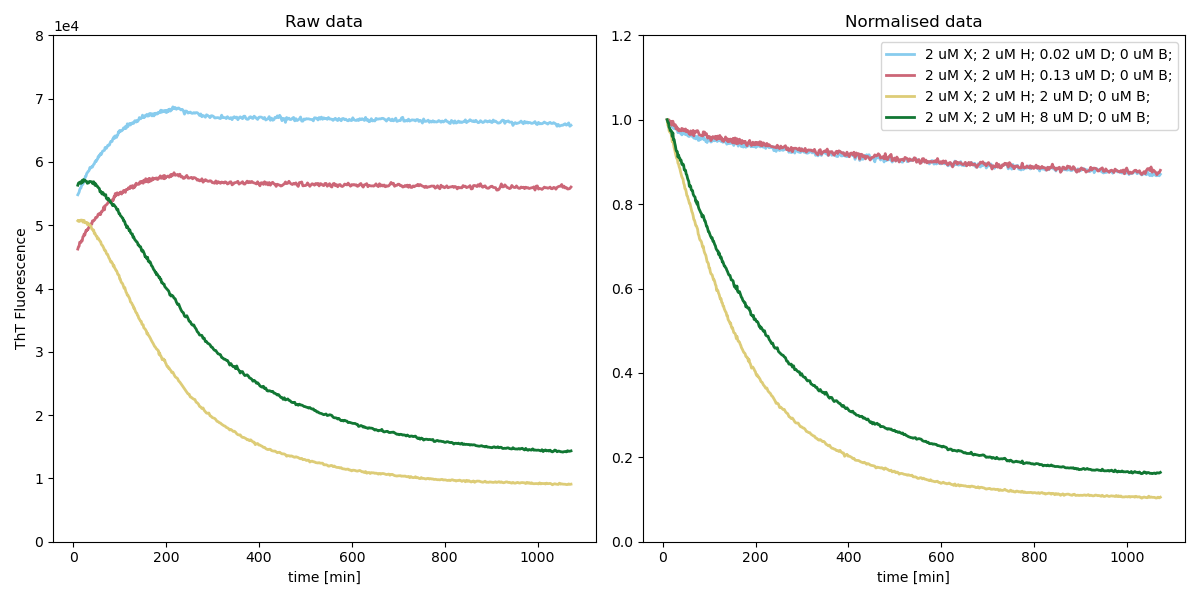

In [8]:
#Visualize data - Normalization
from visualizeData import PlotThT
PlotThT(data, norm)

In [10]:
#Process data - Initial rate
from processData import Process_well
max_time_s = 14*3600 #cut of data after 14 hours
initial_window_s = 60 * 60 # initial-rate fit window
final_window_s = 60 * 60 # endpoint averaging window
window_size = 51 # Savitzky-Golay smoothing window (must be odd)
poly_order = 3  

norm, kinetics = Process_well(
    data, roi,
    Max_time_s=max_time_s,
    Initial_window_s=initial_window_s,
    Final_window_s=final_window_s,
    Window_size=window_size,
    Poly_order=poly_order,
    Mode='off'
)

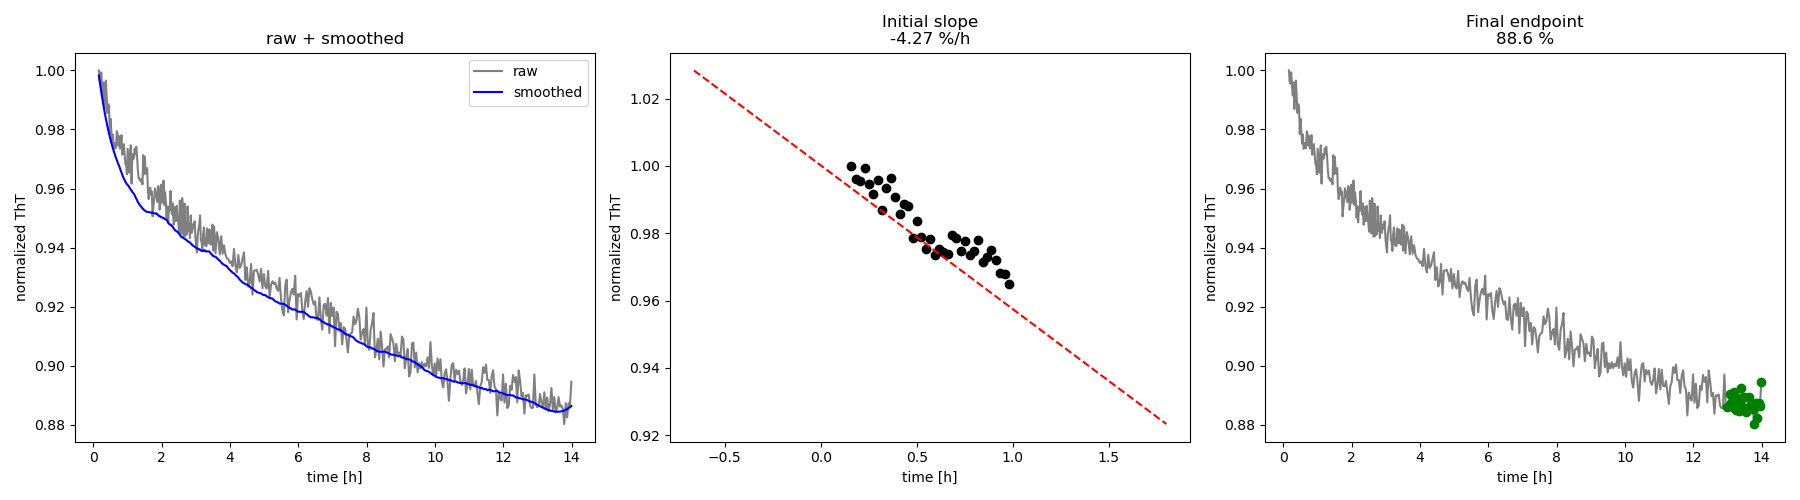

Initial slope window: 574s -> 3526s
Final endpoint window: 46760s -> 50360s
Rate: -4.273 %/h
Endpoint: 88.562 %


In [25]:
#Diagnostics
from visualizeData import PlotThTDiagnostics
k=1
dataNorm = norm[roi['well'].iloc[k]].values.astype(float)
time_s = norm['Time [s]'].values.astype(float)
PlotThTDiagnostics(time_s, dataNorm, kinetics)

'A10'